### **Project Overview**

In this project, I look at **upset matches** in the 2025 ATP Tour. I became interested in this topic because upset matches often get more attention in sports, and they can make a tournament feel less predictable and more interesting.

The dataset I use comes from the [TennisMyLife](https://stats.tennismylife.org/tennis-match-database) Tennis Match Database, which provides public ATP match data in CSV format. It does not seem to be the original official ATP dataset, so I do not want to overstate the source. Still, it includes detailed match-level information such as rankings, tournament level, surface, round, and match statistics, so I think it is appropriate for this class project.

For this analysis, I define an upset match as a **match where the winner had a worse ranking than the loser**. In other words, the lower-ranked player defeats the higher-ranked player.

My main research question is: **What patterns are related to upset matches in the 2025 ATP Tour?**

- Q1. How common were upset matches in the 2025 ATP Tour?
- Q2. Did upset rates vary by surface, tournament level, or round?
- Q3. Were upset matches different from non-upset matches in duration or performance patterns?
- Q4. How large were upset wins, and in which contexts did the biggest upsets happen?

To answer this, I plan to examine overall upset frequency and compare upset rates across surfaces, tournament levels, and rounds. I also want to compare upset and non-upset matches using variables such as match duration and ranking gap.

### **1. Load and Inspect the Dataset**

In [1]:
# Import Library
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Adjust how floating-point numbers are displayed when outputing a pandas Dataframe or series
pd.options.display.float_format = '{:.4f}'.format

In [3]:
# Import dataset
from google.colab import drive
drive.mount('/content/MyDrive')

path = '/content/MyDrive/MyDrive/MESA8411/atp_matches_2025.csv'
df = pd.read_csv(path)

Mounted at /content/MyDrive


In [4]:
# Check the size of the dataset
df.shape

(2944, 50)

In [5]:
# View the Column Names
df.columns

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'indoor', 'tourney_date', 'match_num', 'winner_id', 'winner_seed',
       'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc',
       'winner_age', 'winner_rank', 'winner_rank_points', 'loser_id',
       'loser_seed', 'loser_entry', 'loser_name', 'loser_hand', 'loser_ht',
       'loser_ioc', 'loser_age', 'loser_rank', 'loser_rank_points', 'score',
       'best_of', 'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn',
       'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace',
       'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms',
       'l_bpSaved', 'l_bpFaced'],
      dtype='object')

Database Columns Description:

- `tourney_id`: Tournament ID based on ATP database
- `tourney_name`: City where the tournament was played
- `surface`: Hard, clay, grass, carpet
- `draw_size`: Tournament draw (128, 64, 32, 16, 8, 4)
- `tourney_level`: G (Grand Slam), A (Others ATP Tour Matches), D (Davis Cup), F (ATP Fianls), 250/500/M(equal to 1000) (Greater number means higher ATP Touney level)
- `indoor`: Yes/No
- `tourney_date`: Week of the tournament (YYYYMMDD)
- `match_num`: Match number in the tournament
- `winner_id`: ATP player ID of the winner
- `winner_seed`: Seed of the winner
- `winner_entry`: How the winner entered the tournament (e.g., Q, WC)
- `winner_name`: Full name of the winner
- `winner_hand`: Playing hand of the winner (R/L)
- `winner_ht`: Height of the winner in cm
- `winner_ioc`: Country code of the winner
- `winner_age`: Age of the winner at match time
- `winner_rank`: ATP ranking of the winner at match time
- `winner_rank_points`: ATP ranking points of the - winner at match time
- `loser_id`: ATP player ID of the loser
- `loser_seed`: Seed of the loser
- `loser_entry`: How the loser entered the tournament
- `loser_name`: Full name of the loser
- `loser_hand`: Playing hand of the loser (R/L)
- `loser_ht`: Height of the loser in cm
- `loser_ioc`: Country code of the loser
- `loser_age`: Age of the loser at match time
- `loser_rank`: ATP ranking of the loser at match time
- `loser_rank_points`: ATP ranking points of the loser at match time
- `score`: Final match score (set by set)
- `best_of`: Number of sets (3 or 5)
- `round`: R128, R64, R32, R16, QF, SF, F
- `minutes`: Match duration in minutes

- `w_ace`: Aces by winner
- `w_df`: Double faults by winner
- `w_svpt`: Total serve points by winner
- `w_1stIn`: First serves in by winner
- `w_1stWon`: First serve points won by winner
- `w_2ndWon`: Second serve points won by winner
- `w_SvGms`: Service games played by winner
- `w_bpSaved`: Break points saved by winner
- `w_bpFaced`: Break points faced by winner

- `l_ace`: Aces by loser
- `l_df`: Double faults by loser
- `l_svpt`: Total serve points by loser
- `l_1stIn`: First serves in by loser
- `l_1stWon`: First serve points won by loser
- `l_2ndWon`: Second serve points won by loser
- `l_SvGms`: Service games played by loser
- `l_bpSaved`: Break points saved by loser
- `l_bpFaced`: Break points faced by loser

In [6]:
# Inspect data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2944 entries, 0 to 2943
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          2944 non-null   object 
 1   tourney_name        2944 non-null   object 
 2   surface             2944 non-null   object 
 3   draw_size           2928 non-null   float64
 4   tourney_level       2944 non-null   object 
 5   indoor              2708 non-null   object 
 6   tourney_date        2944 non-null   int64  
 7   match_num           2455 non-null   float64
 8   winner_id           2944 non-null   object 
 9   winner_seed         1200 non-null   float64
 10  winner_entry        305 non-null    object 
 11  winner_name         2944 non-null   object 
 12  winner_hand         2926 non-null   object 
 13  winner_ht           2916 non-null   float64
 14  winner_ioc          2942 non-null   object 
 15  winner_age          2942 non-null   float64
 16  winner

In [7]:
# Preview the first few rows
df.head().T

,0,1,2,3,4
tourney_id,2025-9900,2025-9900,2025-9900,2025-9900,2025-9900
tourney_name,United Cup,United Cup,United Cup,United Cup,United Cup
surface,Hard,Hard,Hard,Hard,Hard
draw_size,18.0000,18.0000,18.0000,18.0000,18.0000
tourney_level,A,A,A,A,A
indoor,O,O,O,O,O
tourney_date,20241229,20241229,20241229,20241229,20241229
match_num,1.0000,2.0000,3.0000,4.0000,5.0000
winner_id,CD85,Z371,TE51,CG80,HH26
winner_seed,NaN,NaN,NaN,NaN,NaN


In [8]:
# Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
draw_size,2928.0000,60.8689,42.4732,2.0000,28.0000,32.0000,96.0000,128.0000
tourney_date,2944.0000,20250310.8526,1575.4018,20241229.0000,20250303.0000,20250526.0000,20250824.0000,20251222.0000
match_num,2455.0000,28.2147,28.9451,1.0000,7.0000,19.0000,37.0000,127.0000
winner_seed,1200.0000,8.6092,7.7689,1.0000,3.0000,6.0000,12.0000,32.0000
winner_ht,2916.0000,187.6214,6.7661,170.0000,183.0000,188.0000,193.0000,211.0000
winner_age,2942.0000,26.3814,4.1111,17.0900,23.5730,26.1270,28.4638,40.6020
winner_rank,2931.0000,84.6455,158.6470,1.0000,17.0000,46.0000,88.5000,2068.0000
winner_rank_points,2931.0000,1938.0389,2150.5852,1.0000,684.0000,1145.0000,2470.0000,12030.0000
loser_seed,700.0000,10.8871,8.8050,1.0000,4.0000,7.5000,16.0000,32.0000
loser_ht,2882.0000,186.7523,7.0039,168.0000,183.0000,185.0000,191.0000,211.0000


In [9]:
# Check missing values
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

,0
winner_entry,2639
loser_entry,2468
loser_seed,2244
winner_seed,1744
match_num,489
minutes,315
indoor,236
l_ace,193
w_bpSaved,193
w_SvGms,193


**Initial Inspection Notes**

- The dataset includes 2,944 matches and 50 columns, so it is large enough for this project and contains both categorical and numerical variables. This gives enough information to study upset patterns across different match contexts.

- The main variables needed for upset analysis, especially `winner_rank` and `loser_rank`, have relatively few missing values compared to many other columns. This suggests that ranking-based upset classification should be possible for most matches.

- At the same time, some variables such as `minutes` and several serve-related statistics have more missing values. Because of that, the number of matches used may vary depending on the specific part of the analysis. Also, the ranking values go quite far down, which suggests that the dataset includes not only top players but also many lower-ranked players.

### **2. Select Relevant Variables**

- Match Info: tourney_name, surface, tourney_level, round, tourney_date
- Player Info: winner_name, loser_name
- Upset Definition: winner_rank, loser_rank
- Basic Output: minutes
- Serce/Performance Ouput: w_ace, l_ace, w_df, l_df, w_svpt, l_svpt, w_1stIn, l_1stIn, w_1stWon, l_1stWon, w_2ndWon, l_2ndWon, w_SvGms, l_SvGms, w_bpSaved, l_bpSaved, w_bpFaced, l_bpFaced
- Variables In-Case: winner_seed, loser_seed, winner_entry, loser_entry

In [10]:
# Select columns relevant to the project
selected_cols = [
    'tourney_name', 'surface', 'tourney_level', 'tourney_date', 'round', 'best_of',
    'winner_name', 'loser_name',
    'winner_rank', 'loser_rank',
    'winner_seed', 'loser_seed',
    'winner_entry', 'loser_entry',
    'score', 'minutes',
    'w_ace', 'l_ace',
    'w_df', 'l_df',
    'w_svpt', 'l_svpt',
    'w_1stIn', 'l_1stIn',
    'w_1stWon', 'l_1stWon',
    'w_2ndWon', 'l_2ndWon',
    'w_SvGms', 'l_SvGms',
    'w_bpSaved', 'l_bpSaved',
    'w_bpFaced', 'l_bpFaced'
]

analysis_df = df[selected_cols].copy()

In [11]:
analysis_df['tourney_date'] = pd.to_datetime(analysis_df['tourney_date'], format='%Y%m%d', errors='coerce')

In [12]:
numeric_cols = ['winner_rank', 'loser_rank', 'minutes', 'w_ace', 'l_ace', 'w_df', 'l_df']
for col in numeric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

In [13]:
# Check the size of the reduced dataset
print("Reduced dataset shape:", analysis_df.shape)
print("\nSelected columns:")
print(list(analysis_df.columns))

Reduced dataset shape: (2944, 34)

Selected columns:
['tourney_name', 'surface', 'tourney_level', 'tourney_date', 'round', 'best_of', 'winner_name', 'loser_name', 'winner_rank', 'loser_rank', 'winner_seed', 'loser_seed', 'winner_entry', 'loser_entry', 'score', 'minutes', 'w_ace', 'l_ace', 'w_df', 'l_df', 'w_svpt', 'l_svpt', 'w_1stIn', 'l_1stIn', 'w_1stWon', 'l_1stWon', 'w_2ndWon', 'l_2ndWon', 'w_SvGms', 'l_SvGms', 'w_bpSaved', 'l_bpSaved', 'w_bpFaced', 'l_bpFaced']


**Variables Selection Notes:**

- I categorized variables to related purpose, and restruct the dataframe to be appropriate to my questions
- Also, I converted the tournament date to datetime and coerced key match statistics to numeric to ensure consistent analysis.

### **3. Clean and Prepare the Data**

In [14]:
# Check missing values in the selected dataset
missing_counts = analysis_df.isnull().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

,0
winner_entry,2639
loser_entry,2468
loser_seed,2244
winner_seed,1744
minutes,315
l_bpFaced,193
w_bpFaced,193
l_ace,193
l_bpSaved,193
w_bpSaved,193


In [15]:
# Check categorical values
print("Surface categories:")
print(analysis_df['surface'].value_counts(dropna=False))

print("\nTournament level categories:")
print(analysis_df['tourney_level'].value_counts(dropna=False))

print("\nRound categories:")
print(analysis_df['round'].value_counts(dropna=False))

Surface categories:
surface
Hard     1860
Clay      787
Grass     297
Name: count, dtype: int64

Tournament level categories:
tourney_level
250    834
M      775
500    513
G      508
D      250
A       49
F       15
Name: count, dtype: int64

Round categories:
round
R32     833
R128    480
R16     472
R64     432
RR      307
QF      236
SF      122
F        62
Name: count, dtype: int64


**Note on 'tourney_level`**

- The description I found for `tourney_level` was a little more general than the actual values in the dataset. For example, it mentioned labels like `G`, `A`, `D`, and `F`, but the dataset also includes `250`, `500`, and `M`. Because of that, I decided to keep the original values from the dataset instead of collapsing them into broader groups. I think this is better for the analysis because it keeps more detail about tournament level.

In [16]:
# Check missing values in ranking columns
print("Missing winner_rank:", analysis_df['winner_rank'].isnull().sum())
print("Missing loser_rank:", analysis_df['loser_rank'].isnull().sum())

analysis_df['rank_missing'] = analysis_df[['winner_rank', 'loser_rank']].isnull().any(axis=1)
print("\nMatches with any missing ranking value:")
print(analysis_df['rank_missing'].value_counts())

Missing winner_rank: 13
Missing loser_rank: 58

Matches with any missing ranking value:
rank_missing
False    2882
True       62
Name: count, dtype: int64


In [17]:
# Keep only matches with both winner and loser rankings for upset analysis
upset_df = analysis_df.dropna(subset=['winner_rank', 'loser_rank']).copy()

print("Original dataset shape:", analysis_df.shape)
print("Upset analysis dataset shape:", upset_df.shape)

Original dataset shape: (2944, 35)
Upset analysis dataset shape: (2882, 35)


In [18]:
# Inspect the upset analysis dataset
upset_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2882 entries, 0 to 2943
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   tourney_name   2882 non-null   object        
 1   surface        2882 non-null   object        
 2   tourney_level  2882 non-null   object        
 3   tourney_date   2882 non-null   datetime64[ns]
 4   round          2882 non-null   object        
 5   best_of        2882 non-null   int64         
 6   winner_name    2882 non-null   object        
 7   loser_name     2882 non-null   object        
 8   winner_rank    2882 non-null   float64       
 9   loser_rank     2882 non-null   float64       
 10  winner_seed    1199 non-null   float64       
 11  loser_seed     700 non-null    float64       
 12  winner_entry   305 non-null    object        
 13  loser_entry    475 non-null    object        
 14  score          2882 non-null   object        
 15  minutes        2625 non-nu

**Cleaning Notes**

- The surface and round variables look relatively clean, with only a few clear categories. This should make grouped comparisons easier later in the analysis.

- The ranking variables have some missing values, but the number is fairly small. Out of 2944 total matches, 2882 matches have both winner and loser rankings available, so most of the dataset can still be used for the main upset analysis.

- One thing to note is that tournament level is stored using short codes such as 250, 500, M, and G. I may keep these codes in the analysis, but I will interpret them carefully when discussing the results.

### **4. Create Variables for Upset Analysis**

In [22]:
# Create upset indicator
upset_df['upset_match'] = (upset_df['winner_rank'] > upset_df['loser_rank']).astype(int)

# Check the distribution
upset_df['upset_match'].value_counts()

,count
upset_match,
0,1849
1,1033


In [23]:
# Create rank gap
upset_df['rank_gap'] = (upset_df['winner_rank'] - upset_df['loser_rank']).abs()

# Summary of rank gap
upset_df['rank_gap'].describe()

,rank_gap
count,2882.0000
mean,83.2002
std,147.9306
min,1.0000
25%,19.0000
50%,42.0000
75%,83.0000
max,1921.0000


In [24]:
# Check potential outliers using IQR
for col in ['rank_gap', 'minutes']:
    temp = upset_df[col].dropna()
    q1 = temp.quantile(0.25)
    q3 = temp.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((temp < lower) | (temp > upper)).sum()
    print(col, 'outliers:', outlier_count, 'out of', len(temp))

rank_gap outliers: 278 out of 2882
minutes outliers: 49 out of 2625


**Outlier Inspection Notes**
- I inspected outliers in rank gap and match duration using the IQR rule. I chose not to remove them automatically because unusually large upsets and very long matches may reflect real competitive events rather than data entry errors.

In [25]:
# Recode round into broader groups
round_map = {
    'R128': 'Early',
    'R64': 'Early',
    'R32': 'Early',
    'R16': 'Middle',
    'QF': 'Middle',
    'SF': 'Late',
    'F': 'Late',
    'RR': 'Round Robin'
}

upset_df['round_group'] = upset_df['round'].map(round_map)

# check the new variable
upset_df['round_group'].value_counts()

,count
round_group,
Early,1741
Middle,708
Round Robin,249
Late,184


In [26]:
# Create simple performance difference variables
upset_df['ace_diff'] = upset_df['w_ace'] - upset_df['l_ace']
upset_df['df_diff'] = upset_df['w_df'] - upset_df['l_df']

# Check summaries
upset_df[['ace_diff', 'df_diff']].describe()

,ace_diff,df_diff
count,2747.0000,2747.0000
mean,1.7576,-0.6705
std,5.8163,2.9630
min,-38.0000,-13.0000
25%,-2.0000,-2.0000
50%,2.0000,-1.0000
75%,5.0000,1.0000
max,36.0000,14.0000


**Variable Creation Notes**

- After correcting the upset indicator, the results look much more reasonable. Out of 2882 matches with available ranking information, 1033 matches were classified as upsets and 1849 were classified as non-upsets. This means upset matches account for about 35.8% of the matches in the upset analysis dataset.

- The rank gap variable also shows that ranking differences vary a lot across matches. The median rank gap is 42, while the mean is about 83, which suggests that the distribution is right-skewed and includes some matches with very large ranking differences.

### **5. Descriptive Overview of Upset Matches**

**- Q1. How common were upset matches?**

In [27]:
# Overall upset rate
total_matches = len(upset_df)
total_upsets = upset_df['upset_match'].sum()
total_non_upsets = total_matches - total_upsets
upset_rate = total_upsets / total_matches

print("Total matches in upset analysis:", total_matches)
print("Non-upset matches:", total_non_upsets)
print("Upset matches:", total_upsets)
print("Upset rate:", round(upset_rate * 100, 2), "%")

Total matches in upset analysis: 2882
Non-upset matches: 1849
Upset matches: 1033
Upset rate: 35.84 %


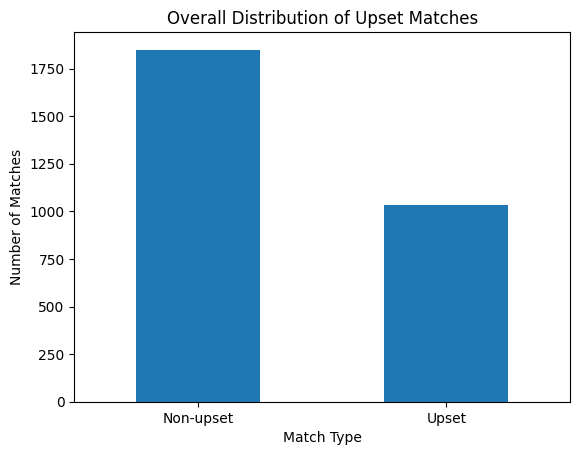

In [28]:
# Bar chart of upset vs non-upset matches
upset_summary_plot = upset_df['upset_match'].value_counts().sort_index()
upset_summary_plot.index = ['Non-upset', 'Upset']

upset_summary_plot.plot(kind='bar')
plt.title('Overall Distribution of Upset Matches')
plt.ylabel('Number of Matches')
plt.xlabel('Match Type')
plt.xticks(rotation=0)
plt.show()

In [29]:
# Selected summary statistics for rank gap
rank_gap_summary = upset_df['rank_gap'].describe()[['count', 'mean', '50%', 'min', 'max']]
rank_gap_summary

,rank_gap
count,2882.0000
mean,83.2002
50%,42.0000
min,1.0000
max,1921.0000


In [30]:
# View upset matches closely
upset_only = upset_df[upset_df['upset_match'] == 1].copy()
upset_only['rank_gap'].describe()

,rank_gap
count,1033.0000
mean,73.5857
std,137.7765
min,1.0000
25%,17.0000
50%,36.0000
75%,75.0000
max,1655.0000


### **6. Grouped Analysis by Surface, Tournament Level, and Round**
**- Q2. Where did upset matches happen more often?**

##### **1) Upset Frequency**

In [31]:
# Upset rate by surface
surface_summary = upset_df.groupby('surface').agg(
    total_matches=('upset_match', 'count'),
    upset_matches=('upset_match', 'sum')
)

surface_summary['upset_rate'] = (surface_summary['upset_matches'] / surface_summary['total_matches'] * 100)

surface_summary.sort_values('upset_rate', ascending=False)

,total_matches,upset_matches,upset_rate
surface,,,
Grass,297,110,37.0370
Hard,1811,649,35.8366
Clay,774,274,35.4005


In [32]:
# Upset rate by tournament level
level_summary = upset_df.groupby('tourney_level').agg(
    total_matches=('upset_match', 'count'),
    upset_matches=('upset_match', 'sum')
)

level_summary['upset_rate'] = (level_summary['upset_matches'] / level_summary['total_matches'] * 100)

level_summary.sort_values('upset_rate', ascending=False)

,total_matches,upset_matches,upset_rate
tourney_level,,,
250,833,342,41.0564
D,192,70,36.4583
M,774,272,35.1421
F,15,5,33.3333
500,513,167,32.5536
G,506,162,32.0158
A,49,15,30.6122


In [33]:
# Upset rate by round
round_summary = upset_df.groupby('round').agg(
    total_matches=('upset_match', 'count'),
    upset_matches=('upset_match', 'sum')
)

round_summary['upset_rate'] = (round_summary['upset_matches'] / round_summary['total_matches'] * 100)

round_summary.sort_values('upset_rate', ascending=False)

,total_matches,upset_matches,upset_rate
round,,,
R128,477,196,41.0901
F,62,24,38.7097
SF,122,44,36.0656
RR,249,89,35.7430
R16,472,168,35.5932
R32,832,290,34.8558
QF,236,82,34.7458
R64,432,140,32.4074


In [34]:
# Upset rate by round_group
round_group_summary = upset_df.groupby('round_group').agg(
    total_matches=('upset_match', 'count'),
    upset_matches=('upset_match', 'sum')
)

round_group_summary['upset_rate'] = (round_group_summary['upset_matches'] / round_group_summary['total_matches'] * 100)

round_group_summary.sort_values('upset_rate', ascending=False)

,total_matches,upset_matches,upset_rate
round_group,,,
Late,184,68,36.9565
Early,1741,626,35.9563
Round Robin,249,89,35.7430
Middle,708,250,35.3107


**Notes on Grouped upset Frequency**

- This grouped results show that upset rates are fairly similar across surfaces, with only small differences between grass, hard, and clay. Tournament level seems to matter a little more, since ATP 250 events have the highest upset rate, while ATP 500 and Grand Slam events are somewhat lower.

- Round also shows some differences, especially in the earliest rounds, but the broader round-group categories are still relatively close to each other. So overall, surface does not seem to separate upset rates very strongly, while tournament level may matter more.

##### **2) Grouped Upset Rates**

a. surface × tournament level

In [35]:
# Upset rate by surface and tournament level
surface_level_summary = upset_df.groupby(['surface', 'tourney_level']).agg(
    total_matches=('upset_match', 'count'),
    upset_matches=('upset_match', 'sum')
)

surface_level_summary['upset_rate'] = (
    surface_level_summary['upset_matches'] / surface_level_summary['total_matches'] * 100
).round(2)

surface_level_summary.sort_values(['surface', 'upset_rate'], ascending=[True, False])

total_matches  upset_matches  upset_rate
surface tourney_level                                          
Clay    D                         35             16     45.7100
        250                      243            101     41.5600
        M                        245             83     33.8800
        G                        127             38     29.9200
        500                      124             36     29.0300
Grass   250                      108             43     39.8100
        500                       62             24     38.7100
        G                        127             43     33.8600
Hard    250                      482            198     41.0800
        M                        529            189     35.7300
        D                        157             54     34.3900
        F                         15              5     33.3300
        500                      327            107     32.7200
        G                        252             81     32.1400
        A                         49             15     30.6100

b. tournament level × round_group

In [36]:
# Upset rate by tournament level and round_group
level_round_summary = upset_df.groupby(['tourney_level', 'round_group']).agg(
    total_matches=('upset_match', 'count'),
    upset_matches=('upset_match', 'sum')
)

level_round_summary['upset_rate'] = (
    level_round_summary['upset_matches'] / level_round_summary['total_matches'] * 100
).round(2)

level_round_summary.sort_values(['tourney_level', 'upset_rate'], ascending=[True, False])

total_matches  upset_matches  upset_rate
tourney_level round_group                                          
250           Early                  383            163     42.5600
              Late                    90             38     42.2200
              Middle                 360            141     39.1700
500           Middle                 192             66     34.3800
              Early                  273             88     32.2300
              Late                    48             13     27.0800
A             Round Robin             45             15     33.3300
              Late                     4              0      0.0000
D             Round Robin            192             70     36.4600
F             Late                     3              1     33.3300
              Round Robin             12              4     33.3300
G             Early                  446            154     34.5300
              Late                    12              2     16.6700
              Middle                  48              6     12.5000
M             Late                    27             14     51.8500
              Early                  639            221     34.5900
              Middle                 108             37     34.2600

c. surface × round_group

In [37]:
# Upset rate by surface and round_group
surface_round_summary = upset_df.groupby(['surface', 'round_group']).agg(
    total_matches=('upset_match', 'count'),
    upset_matches=('upset_match', 'sum')
)

surface_round_summary['upset_rate'] = (
    surface_round_summary['upset_matches'] / surface_round_summary['total_matches'] * 100
).round(2)

surface_round_summary.sort_values(['surface', 'upset_rate'], ascending=[True, False])

total_matches  upset_matches  upset_rate
surface round_group                                          
Clay    Round Robin             35             16     45.7100
        Middle                 204             81     39.7100
        Early                  484            161     33.2600
        Late                    51             16     31.3700
Grass   Late                    21              9     42.8600
        Early                  192             80     41.6700
        Middle                  84             21     25.0000
Hard    Late                   112             43     38.3900
        Early                 1065            385     36.1500
        Middle                 420            148     35.2400
        Round Robin            214             73     34.1100

In [38]:
# Keep only combinations with at least 20 matches
## some of the grouped combinations have fairly small sample sizes,
## so I do not want to over-interpret every percentage in the two-way grouped tables.
## For that reason,  I also look at versions with a minimum match count to focus more on patterns that seem more stable.
surface_level_filtered = surface_level_summary[surface_level_summary['total_matches'] >= 20]
level_round_filtered = level_round_summary[level_round_summary['total_matches'] >= 20]
surface_round_filtered = surface_round_summary[surface_round_summary['total_matches'] >= 20]

In [39]:
surface_level_filtered.sort_values(['surface', 'upset_rate'], ascending=[True, False])

total_matches  upset_matches  upset_rate
surface tourney_level                                          
Clay    D                         35             16     45.7100
        250                      243            101     41.5600
        M                        245             83     33.8800
        G                        127             38     29.9200
        500                      124             36     29.0300
Grass   250                      108             43     39.8100
        500                       62             24     38.7100
        G                        127             43     33.8600
Hard    250                      482            198     41.0800
        M                        529            189     35.7300
        D                        157             54     34.3900
        500                      327            107     32.7200
        G                        252             81     32.1400
        A                         49             15     30.6100

In [40]:
level_round_filtered.sort_values(['tourney_level', 'upset_rate'], ascending=[True, False])

total_matches  upset_matches  upset_rate
tourney_level round_group                                          
250           Early                  383            163     42.5600
              Late                    90             38     42.2200
              Middle                 360            141     39.1700
500           Middle                 192             66     34.3800
              Early                  273             88     32.2300
              Late                    48             13     27.0800
A             Round Robin             45             15     33.3300
D             Round Robin            192             70     36.4600
G             Early                  446            154     34.5300
              Middle                  48              6     12.5000
M             Late                    27             14     51.8500
              Early                  639            221     34.5900
              Middle                 108             37     34.2600

In [41]:
surface_round_filtered.sort_values(['surface', 'upset_rate'], ascending=[True, False])

total_matches  upset_matches  upset_rate
surface round_group                                          
Clay    Round Robin             35             16     45.7100
        Middle                 204             81     39.7100
        Early                  484            161     33.2600
        Late                    51             16     31.3700
Grass   Late                    21              9     42.8600
        Early                  192             80     41.6700
        Middle                  84             21     25.0000
Hard    Late                   112             43     38.3900
        Early                 1065            385     36.1500
        Middle                 420            148     35.2400
        Round Robin            214             73     34.1100

**Deeper Grouped Upset_Rate Analysis Notes**

- The two-way grouped results help show whether the earlier patterns stay similar across more specific match contexts.

- One pattern that looks fairly consistent is the relatively high upset rate in ATP 250 events. This appears on clay, hard, and grass courts, so it does not seem to come from only one surface category. In that sense, tournament level seems to separate upset rates more clearly than surface.

- The two-way results also suggest that round effects may depend on tournament context. In ATP 250 events, upset rates stay relatively high across early, middle, and late rounds, while in other tournament levels the pattern is less consistent. This may mean that round alone does not explain upset frequency very strongly unless it is considered together with tournament type.

- Another thing that stands out is that round-robin categories seem somewhat different from the standard knockout rounds. Since those matches follow a different competition format, I would interpret them more cautiously rather than treating them as directly comparable to all other round groups.

- At the same time, some subgroup counts are small, so I do not want to over-interpret every percentage. I think the more useful takeaway is to focus on patterns that show up more than once across larger groups.

##### **2) Upset_magnitude**

In [42]:
# Upset magnitude by surface
upset_only.groupby('surface')['rank_gap'].agg(['count', 'mean', 'median', 'max']).sort_values('median', ascending=False)

,count,mean,median,max
surface,,,,
Grass,110,63.4455,39.5000,439.0000
Clay,274,76.0985,37.0000,1655.0000
Hard,649,74.2435,36.0000,1645.0000


In [43]:
# Upset magnitude by tournament level
upset_only.groupby('tourney_level')['rank_gap'].agg(['count', 'mean', 'median', 'max']).sort_values('mean', ascending=False)

,count,mean,median,max
tourney_level,,,,
D,70,244.4000,111.0000,1655.0000
250,342,69.0409,41.0000,620.0000
G,162,61.8642,41.0000,439.0000
M,272,60.0735,33.0000,919.0000
500,167,50.1138,28.0000,520.0000
A,15,36.7333,18.0000,140.0000
F,5,2.4000,2.0000,5.0000


In [44]:
# Upset magnitude by round
upset_only.groupby('round')['rank_gap'].agg(['count', 'mean', 'median', 'max']).sort_values('median', ascending=False)

,count,mean,median,max
round,,,,
RR,89,198.5393,90.0000,1655.0000
R64,140,70.9214,43.5000,919.0000
R128,196,68.2347,40.5000,875.0000
R16,168,55.9345,34.5000,475.0000
SF,44,53.2727,32.0000,494.0000
R32,290,63.2241,31.5000,620.0000
QF,82,46.6220,28.5000,428.0000
F,24,47.5833,11.0000,490.0000


In [45]:
# Upset magnitude by round_group
upset_only.groupby('round_group')['rank_gap'].agg(['count', 'mean', 'median', 'max']).sort_values('median', ascending=False)

,count,mean,median,max
round_group,,,,
Round Robin,89,198.5393,90.0000,1655.0000
Early,626,66.5144,37.0000,919.0000
Middle,250,52.8800,31.5000,475.0000
Late,68,51.2647,22.5000,494.0000


In [46]:
# Biggest upsets
upset_only[['winner_name', 'loser_name', 'winner_rank', 'loser_rank', 'surface', 'tourney_level', 'round', 'rank_gap']] \
    .sort_values('rank_gap', ascending=False) \
    .head(10)

,winner_name,loser_name,winner_rank,loser_rank,surface,tourney_level,round,rank_gap
360,Darian King,Nicolas Mejia,1869.0000,214.0000,Clay,D,RR,1655.0000
404,Stylianos Christodoulou,Kasidit Samrej,2068.0000,423.0000,Hard,D,RR,1645.0000
359,Darian King,Adria Soriano Barrera,1869.0000,345.0000,Clay,D,RR,1524.0000
405,Andreas Timini,Thanapet Chanta,2068.0000,706.0000,Hard,D,RR,1362.0000
300,Ofek Shimanov,Daniel Masur,1226.0000,265.0000,Hard,D,RR,961.0000
754,Jenson Brooksby,Felix Auger-Aliassime,937.0000,18.0000,Hard,M,R64,919.0000
716,Jenson Brooksby,Benjamin Bonzi,937.0000,62.0000,Hard,M,R128,875.0000
2346,Alexander Vasilev,Otto Virtanen,992.0000,141.0000,Clay,D,RR,851.0000
832,Nick Kyrgios,Mackenzie McDonald,892.0000,101.0000,Hard,M,R128,791.0000
398,Christopher Bulus,Kris Van Wyk,1018.0000,358.0000,Hard,D,RR,660.0000


**Upset Magnitude Notes**

- Looking only at matches classified as upsets, the gap between mean and median rank gap is noticeable in almost every category. This suggests that upset magnitude is **right-skewed**, meaning that a small number of very large upsets raise the average. Because of that, median rank gap is helpful for showing what a more typical upset looks like.

- By surface, upset magnitude does not seem to differ very strongly. The median rank gap is fairly similar across clay, hard, and grass. This suggests that surface may matter more for upset frequency than for the typical size of the upset.

- Tournament level and round structure seem to matter more. Davis Cup and Round Robin matches show especially large upset magnitudes, which may reflect their more unusual match structure and wider ranking variation. In contrast, ATP Finals has a very small upset magnitude, which makes sense because the players are already very close in ranking.

- Across round groups, the median rank gap becomes smaller from early rounds to later rounds. This suggests that while upsets still happen in later rounds, they tend to occur between players who are closer in ranking.

### **7. Compare Upset and Non-Upset Matches**
**- Q3. How were upset matches different from non-upset matches?**

In [47]:
# Number of matches by upset status
upset_df['upset_match'].value_counts()

,count
upset_match,
0,1849
1,1033


In [48]:
# Summary statistics by upset status
comparison_summary = upset_df.groupby('upset_match')[['minutes', 'rank_gap', 'ace_diff', 'df_diff']].agg(['count', 'mean', 'median'])
comparison_summary

minutes                   rank_gap                 ace_diff  \
              count     mean   median    count    mean  median    count   
upset_match                                                               
0              1676 112.5811 104.0000     1849 88.5717 46.0000     1763   
1               949 120.6270 112.0000     1033 73.5857 36.0000      984   

                          df_diff                  
              mean median   count    mean  median  
upset_match                                        
0           2.1900 2.0000    1763 -0.6529 -1.0000  
1           0.9827 1.0000     984 -0.7022 -1.0000

In [49]:
# Additional statistics by upset status
comparison_additional = upset_df.groupby('upset_match')[['w_ace', 'l_ace', 'w_df', 'l_df']].agg(['count', 'mean', 'median'])
comparison_additional

w_ace               l_ace                w_df                l_df  \
            count   mean median count   mean median count   mean median count   
upset_match                                                                     
0            1764 7.5448 7.0000  1763 5.3551 4.0000  1764 2.4473 2.0000  1763   
1             984 7.2703 6.0000   984 6.2876 5.0000   984 2.7215 2.0000   984   

                           
              mean median  
upset_match                
0           3.1010 3.0000  
1           3.4238 3.0000

**Comparing Upset and Non-Upset Matches**

- From these results, upset matches seem to be a little longer than non-upset matches. The mean and median minutes are both higher for upset matches, so this makes it seem like upset wins may happen more often in matches that are more competitive or take longer to finish.

- Upset matches also have smaller rank gaps on average. This seems reasonable because even though an upset means the lower-ranked player wins, it still looks like many of these upsets happen when the two players are not extremely far apart in ranking.

- The ace results are also interesting. Winners in upset matches still usually have more aces than losers, but the gap is smaller than in non-upset matches. This may mean that upset winners are winning without being as dominant in serve advantage.

- The double fault results do not look very different between the two groups. In both cases, winners tend to have slightly fewer double faults than losers, but this does not seem like a major difference between upset and non-upset matches.

### **8. Visualizations**

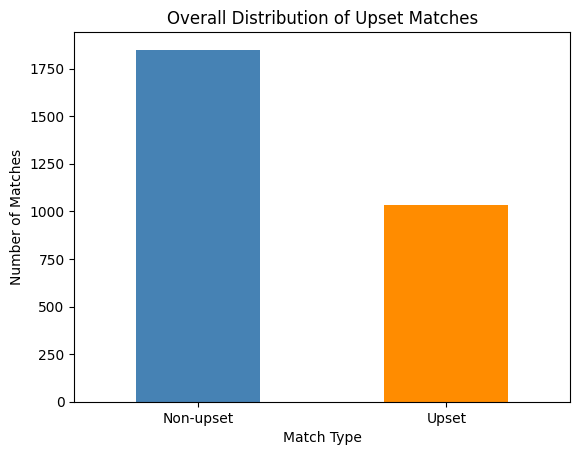

In [50]:
# Bar chart for overall upset distribution with different colors
upset_summary_plot = upset_df['upset_match'].value_counts().sort_index()
upset_summary_plot.index = ['Non-upset', 'Upset']

ax = upset_summary_plot.plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title('Overall Distribution of Upset Matches')
plt.xlabel('Match Type')
plt.ylabel('Number of Matches')
plt.xticks(rotation=0)
plt.show()

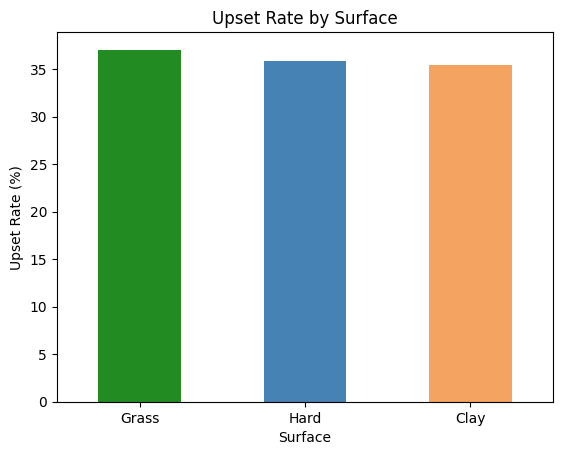

In [51]:
# Bar chart for upset rate by surface with different colors
surface_plot = surface_summary['upset_rate'].sort_values(ascending=False)

ax = surface_plot.plot(kind='bar', color=['forestgreen', 'steelblue', 'sandybrown'])
plt.title('Upset Rate by Surface')
plt.xlabel('Surface')
plt.ylabel('Upset Rate (%)')
plt.xticks(rotation=0)
plt.show()

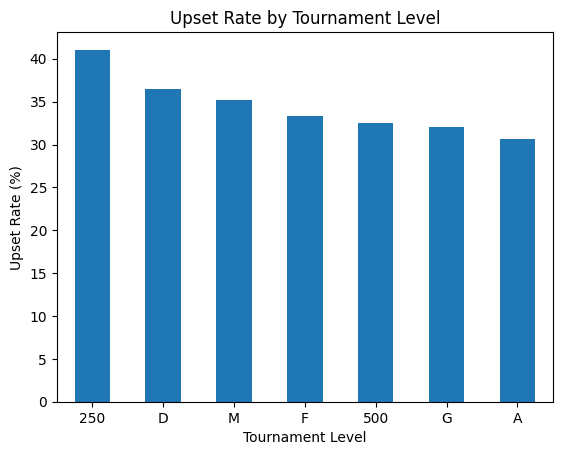

In [52]:
# Bar chart for upset rate by tournament level
level_summary['upset_rate'].sort_values(ascending=False).plot(kind='bar')
plt.title('Upset Rate by Tournament Level')
plt.xlabel('Tournament Level')
plt.ylabel('Upset Rate (%)')
plt.xticks(rotation=0)
plt.show()

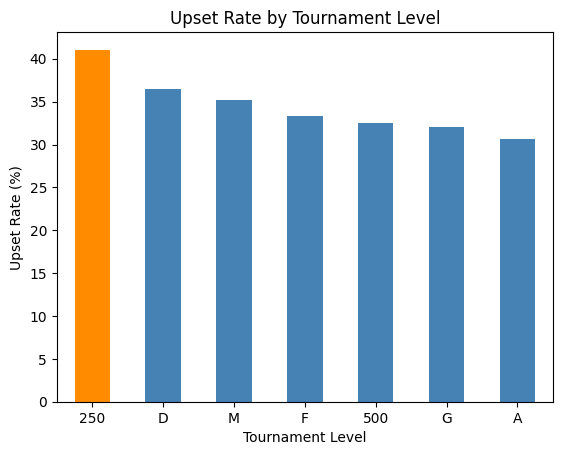

In [53]:
# Highlight ATP 250 while keeping others neutral
level_plot = level_summary['upset_rate'].sort_values(ascending=False)

colors = ['darkorange' if idx == '250' else 'steelblue' for idx in level_plot.index]

ax = level_plot.plot(kind='bar', color=colors)
plt.title('Upset Rate by Tournament Level')
plt.xlabel('Tournament Level')
plt.ylabel('Upset Rate (%)')
plt.xticks(rotation=0)
plt.show()

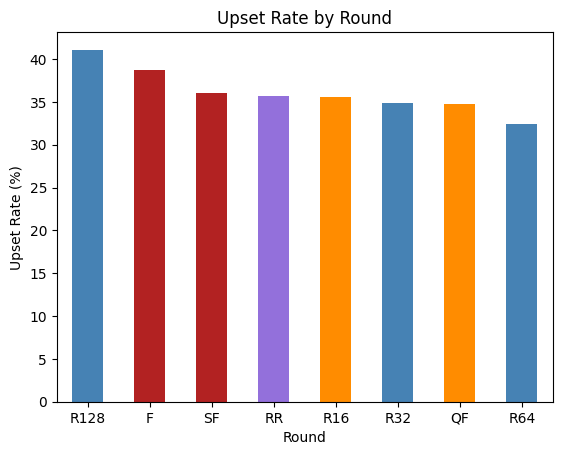

In [54]:
# Bar chart for upset rate by round with stage-based colors
round_plot = round_summary['upset_rate'].sort_values(ascending=False)

round_colors = {
    'R128': 'steelblue',
    'R64': 'steelblue',
    'R32': 'steelblue',
    'R16': 'darkorange',
    'QF': 'darkorange',
    'SF': 'firebrick',
    'F': 'firebrick',
    'RR': 'mediumpurple'
}

bar_colors = [round_colors[r] for r in round_plot.index]

ax = round_plot.plot(kind='bar', color=bar_colors)
plt.title('Upset Rate by Round')
plt.xlabel('Round')
plt.ylabel('Upset Rate (%)')
plt.xticks(rotation=0)
plt.show()

**Viz 1, 2, 3 and 4 Interpretation**

- This helps summarize how common upset matches were in the 2025 ATP dataset and how upset rates changed across different match contexts.

- The overall distribution shows that non-upset matches were still more common than upset matches, but upset matches still made up a substantial share of the dataset. This suggests that upsets were not rare events, even though the expected result happened more often overall.

- The surface chart shows only small differences across grass, hard, and clay. Grass has the highest upset rate, but the gap is not very large, so surface alone does not seem to separate upset frequency very strongly.

- The tournament-level chart shows clearer variation. ATP 250 events have the highest upset rate, while ATP 500 and Grand Slam events are lower. This matches the earlier grouped results and suggests that tournament level may be more useful than surface for understanding where upsets happen more often.

- The round-level graph shows that upset rates are highest in R128, which makes the earliest round stand out the most. This may mean that first-round matches create more chances for unexpected results. Still, most of the other rounds are not extremely far apart, so round does not seem to create a huge difference by itself. Also, some of the later rounds have fewer matches, so I do not want to over-interpret those percentages too strongly.

**Important Note on Smaller Tournament Categories**

- Some tournament-level categories, especially `A`(other ATP matches) and `F`(ATP Finals), have relatively small numbers of matches compared to ATP 250, ATP 500, Masters, and Grand Slam events. `D`(Davis Cup) is also different from the standard ATP tour structure because Davis Cup matches follow a different competition format.

- Because of that, I interpret results for these categories more cautiously and avoid treating their percentages as equally stable. However, I decided to keep them in the analysis rather than remove them completely, because they are still part of the 2025 dataset and help show the full range of tournament contexts included in the data. I treat them as descriptive categories, while placing more weight on patterns that also appear in the larger groups.

/tmp/ipykernel_1948/2927114887.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot([non_upset_minutes, upset_minutes],


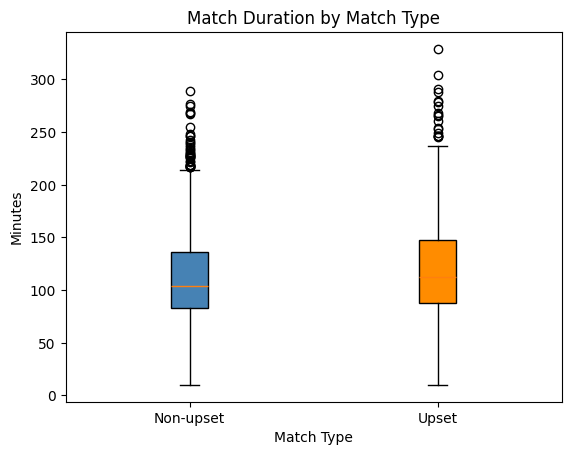

In [55]:
# Boxplot for match duration by match type with different colors
plot_df = upset_df[['upset_match', 'minutes']].dropna().copy()
non_upset_minutes = plot_df.loc[plot_df['upset_match'] == 0, 'minutes']
upset_minutes = plot_df.loc[plot_df['upset_match'] == 1, 'minutes']

fig, ax = plt.subplots()
box = ax.boxplot([non_upset_minutes, upset_minutes],
                 labels=['Non-upset', 'Upset'],
                 patch_artist=True)

colors = ['steelblue', 'darkorange']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Match Duration by Match Type')
plt.xlabel('Match Type')
plt.ylabel('Minutes')
plt.show()

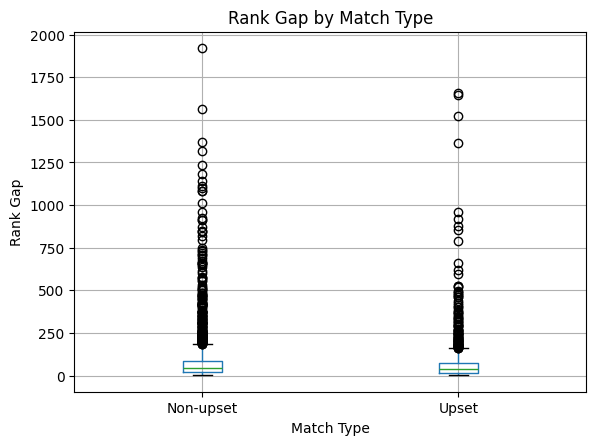

In [56]:
# Boxplot for rank gap by upset status
plot_df = upset_df[['upset_match', 'rank_gap']].dropna().copy()
plot_df['match_type'] = plot_df['upset_match'].map({0: 'Non-upset', 1: 'Upset'})

plot_df.boxplot(column='rank_gap', by='match_type')
plt.title('Rank Gap by Match Type')
plt.suptitle('')
plt.xlabel('Match Type')
plt.ylabel('Rank Gap')
plt.show()

/tmp/ipykernel_1948/335540050.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot([non_upset_gap, upset_gap],


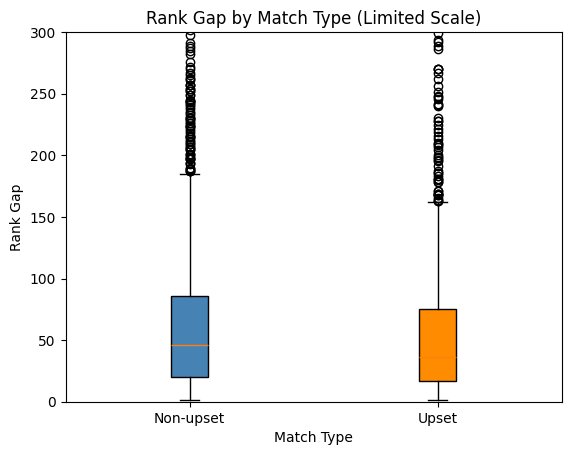

In [57]:
# Boxplot for rank gap by match type with different colors
plot_df = upset_df[['upset_match', 'rank_gap']].dropna().copy()
non_upset_gap = plot_df.loc[plot_df['upset_match'] == 0, 'rank_gap']
upset_gap = plot_df.loc[plot_df['upset_match'] == 1, 'rank_gap']

fig, ax = plt.subplots()
box = ax.boxplot([non_upset_gap, upset_gap],
                 labels=['Non-upset', 'Upset'],
                 patch_artist=True)

colors = ['steelblue', 'darkorange']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Rank Gap by Match Type (Limited Scale)')
plt.xlabel('Match Type')
plt.ylabel('Rank Gap')
plt.ylim(0, 300)
plt.show()

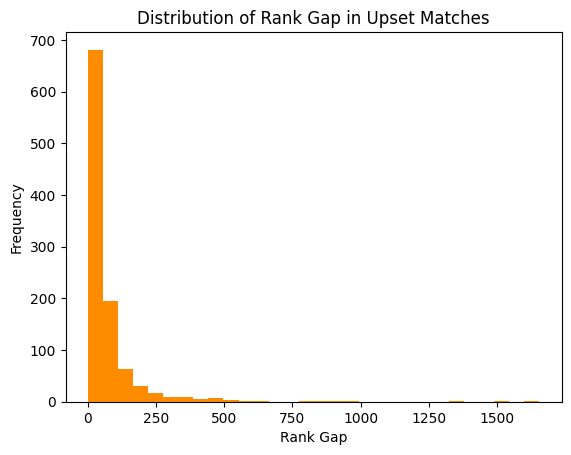

In [58]:
# Histogram of rank gap among upset matches
upset_only['rank_gap'].plot(kind='hist', bins=30, color='darkorange')
plt.title('Distribution of Rank Gap in Upset Matches')
plt.xlabel('Rank Gap')
plt.ylabel('Frequency')
plt.show()

**Viz 4,5, and 6 Interpretation**

- The boxplot for match duration shows that upset matches tend to last longer than non-upset matches. This matches the earlier summary statistics and suggests that upset wins may happen more often in longer and more competitive matches.

- The rank gap boxplot shows that upset matches usually happen when the two players are closer in ranking than in non-upset matches. Even though some very large upsets do occur, the typical upset seems to happen in matches where the ranking gap is not extremely large.

- The histogram of rank gap among upset matches also supports this pattern. The distribution is strongly right-skewed, which means that a few very large upsets raise the upper tail, but most upset matches still happen at smaller or moderate ranking gaps. These visualizations also help explain why median rank gap was useful in the upset magnitude analysis. Because the upset rank-gap distribution has a long right tail, the mean can be pulled upward by a small number of unusually large upsets, while the median gives a more typical sense of upset size.

**Overall Insight Supported by Visualizations Collectively**

- psets were not rare in the 2025 ATP Tour, but they were not distributed evenly. Surface alone did not explain much, while tournament level, especially ATP 250 events, showed a clearer pattern.
- At the same time, most upsets were not huge shocks between extremely distant rankings. They more often happened in relatively competitive matches that lasted longer and involved players who were still somewhat close in rank.

### **9. Notable Upset Matches**
**- Q4. What did the biggest upsets look like?**

In [59]:
# Keep only upset matches
upset_only = upset_df[upset_df['upset_match'] == 1].copy()

print("Number of upset matches:", len(upset_only))
upset_only.head()

Number of upset matches: 1033


,tourney_name,surface,tourney_level,tourney_date,round,best_of,winner_name,loser_name,winner_rank,loser_rank,...,w_bpSaved,l_bpSaved,w_bpFaced,l_bpFaced,rank_missing,upset_match,rank_gap,round_group,ace_diff,df_diff
0,United Cup,Hard,A,2024-12-29,RR,3,Pablo Carreno Busta,Alexander Shevchenko,196.0000,78.0000,...,1.0000,2.0000,2.0000,7.0000,False,1,118.0000,Round Robin,0.0000,-4.0000
3,United Cup,Hard,A,2024-12-29,RR,3,Borna Coric,Felix Auger-Aliassime,90.0000,29.0000,...,5.0000,8.0000,10.0000,12.0000,False,1,61.0000,Round Robin,-12.0000,3.0000
6,United Cup,Hard,A,2024-12-29,RR,3,Felix Auger-Aliassime,Taylor Fritz,29.0000,4.0000,...,2.0000,1.0000,4.0000,4.0000,False,1,25.0000,Round Robin,6.0000,3.0000
11,United Cup,Hard,A,2024-12-29,RR,3,Alexander Shevchenko,Stefanos Tsitsipas,78.0000,11.0000,...,1.0000,2.0000,2.0000,4.0000,False,1,67.0000,Round Robin,-5.0000,-1.0000
15,United Cup,Hard,A,2024-12-29,RR,3,Flavio Cobolli,Ugo Humbert,32.0000,14.0000,...,2.0000,1.0000,4.0000,4.0000,False,1,18.0000,Round Robin,1.0000,-2.0000


In [60]:
# Top 10 biggest upset matches overall
top_upsets = upset_only[
    ['winner_name', 'loser_name', 'winner_rank', 'loser_rank', 'rank_gap',
     'surface', 'tourney_level', 'round', 'tourney_name', 'minutes', 'score']
].sort_values('rank_gap', ascending=False).head(10)

top_upsets

,winner_name,loser_name,winner_rank,loser_rank,rank_gap,surface,tourney_level,round,tourney_name,minutes,score
360,Darian King,Nicolas Mejia,1869.0000,214.0000,1655.0000,Clay,D,RR,Davis Cup WG1 PO: COL vs BRB,NaN,6-3 6-4
404,Stylianos Christodoulou,Kasidit Samrej,2068.0000,423.0000,1645.0000,Hard,D,RR,Davis Cup WG2 PO: CYP vs THA,NaN,1-6 6-0 6-4
359,Darian King,Adria Soriano Barrera,1869.0000,345.0000,1524.0000,Clay,D,RR,Davis Cup WG1 PO: COL vs BRB,NaN,6-2 6-4
405,Andreas Timini,Thanapet Chanta,2068.0000,706.0000,1362.0000,Hard,D,RR,Davis Cup WG2 PO: CYP vs THA,NaN,6-3 6-3
300,Ofek Shimanov,Daniel Masur,1226.0000,265.0000,961.0000,Hard,D,RR,Davis Cup QLS R1: ISR vs GER,NaN,7-6(2) 3-6 [10-8]
754,Jenson Brooksby,Felix Auger-Aliassime,937.0000,18.0000,919.0000,Hard,M,R64,Indian Wells Masters,88.0000,6-4 6-2
716,Jenson Brooksby,Benjamin Bonzi,937.0000,62.0000,875.0000,Hard,M,R128,Indian Wells Masters,150.0000,1-6 7-5 7-5
2346,Alexander Vasilev,Otto Virtanen,992.0000,141.0000,851.0000,Clay,D,RR,Davis Cup WG1 R1: BUL vs FIN,110.0000,6-3 7-5
832,Nick Kyrgios,Mackenzie McDonald,892.0000,101.0000,791.0000,Hard,M,R128,Miami Masters,103.0000,3-6 6-3 6-4
398,Christopher Bulus,Kris Van Wyk,1018.0000,358.0000,660.0000,Hard,D,RR,Davis Cup WG2 PO: RSA vs NGR,NaN,3-6 6-3 7-6(4)


In [61]:
# Top 10 biggest upsets excluding Davis Cup
top_upsets_no_d = upset_only[upset_only['tourney_level'] != 'D'][
    ['winner_name', 'loser_name', 'winner_rank', 'loser_rank', 'rank_gap',
     'surface', 'tourney_level', 'round', 'tourney_name', 'minutes', 'score']
].sort_values('rank_gap', ascending=False).head(10)

top_upsets_no_d

,winner_name,loser_name,winner_rank,loser_rank,rank_gap,surface,tourney_level,round,tourney_name,minutes,score
754,Jenson Brooksby,Felix Auger-Aliassime,937.0000,18.0000,919.0000,Hard,M,R64,Indian Wells Masters,88.0000,6-4 6-2
716,Jenson Brooksby,Benjamin Bonzi,937.0000,62.0000,875.0000,Hard,M,R128,Indian Wells Masters,150.0000,1-6 7-5 7-5
832,Nick Kyrgios,Mackenzie McDonald,892.0000,101.0000,791.0000,Hard,M,R128,Miami Masters,103.0000,3-6 6-3 6-4
1777,Luis Carlos Alvarez,James McCabe,784.0000,164.0000,620.0000,Hard,250,R32,Los Cabos,73.0000,6-1 6-2
1975,Nicolas Arseneault,Valentin Royer,638.0000,111.0000,527.0000,Hard,M,R128,Canada Masters,103.0000,6-3 7-6(4)
1075,Diego Dedura-Palomero,Denis Shapovalov,549.0000,29.0000,520.0000,Clay,500,R32,Munich,63.0000,7-6(2) 3-0 RET
928,Jenson Brooksby,Tommy Paul,507.0000,13.0000,494.0000,Clay,250,SF,Houston,162.0000,7-6(5) 3-6 7-6(6)
930,Jenson Brooksby,Frances Tiafoe,507.0000,17.0000,490.0000,Clay,250,F,Houston,87.0000,6-4 6-2
2651,Leo Borg,Sebastian Ofner,622.0000,140.0000,482.0000,Hard,250,R32,Stockholm,75.0000,6-3 6-4
921,Jenson Brooksby,Alejandro Tabilo,507.0000,32.0000,475.0000,Clay,250,R16,Houston,169.0000,3-6 6-4 7-6(6)


Why I Also Excluded Davis Cup Here

- I did not remove Davis Cup from the full analysis, but I wanted to look at a version without it in this section. The reason is that Davis Cup uses a different format and seems to include some unusually large ranking gaps, so the biggest upsets can get dominated by those matches.

- By looking at the results without Davis Cup, it becomes easier to see which upset matches stand out within a more regular ATP tournament setting.

In [62]:
# Top 10 biggest upsets excluding Davis Cup and Round Robin
top_upsets_no_d_rr = upset_only[
    (upset_only['tourney_level'] != 'D') & (upset_only['round'] != 'RR')
][[
    'winner_name', 'loser_name', 'winner_rank', 'loser_rank', 'rank_gap',
    'surface', 'tourney_level', 'round', 'tourney_name', 'minutes', 'score'
]].sort_values('rank_gap', ascending=False).head(10)

top_upsets_no_d_rr

,winner_name,loser_name,winner_rank,loser_rank,rank_gap,surface,tourney_level,round,tourney_name,minutes,score
754,Jenson Brooksby,Felix Auger-Aliassime,937.0000,18.0000,919.0000,Hard,M,R64,Indian Wells Masters,88.0000,6-4 6-2
716,Jenson Brooksby,Benjamin Bonzi,937.0000,62.0000,875.0000,Hard,M,R128,Indian Wells Masters,150.0000,1-6 7-5 7-5
832,Nick Kyrgios,Mackenzie McDonald,892.0000,101.0000,791.0000,Hard,M,R128,Miami Masters,103.0000,3-6 6-3 6-4
1777,Luis Carlos Alvarez,James McCabe,784.0000,164.0000,620.0000,Hard,250,R32,Los Cabos,73.0000,6-1 6-2
1975,Nicolas Arseneault,Valentin Royer,638.0000,111.0000,527.0000,Hard,M,R128,Canada Masters,103.0000,6-3 7-6(4)
1075,Diego Dedura-Palomero,Denis Shapovalov,549.0000,29.0000,520.0000,Clay,500,R32,Munich,63.0000,7-6(2) 3-0 RET
928,Jenson Brooksby,Tommy Paul,507.0000,13.0000,494.0000,Clay,250,SF,Houston,162.0000,7-6(5) 3-6 7-6(6)
930,Jenson Brooksby,Frances Tiafoe,507.0000,17.0000,490.0000,Clay,250,F,Houston,87.0000,6-4 6-2
2651,Leo Borg,Sebastian Ofner,622.0000,140.0000,482.0000,Hard,250,R32,Stockholm,75.0000,6-3 6-4
921,Jenson Brooksby,Alejandro Tabilo,507.0000,32.0000,475.0000,Clay,250,R16,Houston,169.0000,3-6 6-4 7-6(6)


In [63]:
# Biggest upset on each surface
surface_top_upsets = upset_only.sort_values('rank_gap', ascending=False) \
    .groupby('surface', as_index=False) \
    .first()[['surface', 'winner_name', 'loser_name', 'winner_rank', 'loser_rank',
              'rank_gap', 'tourney_level', 'round', 'tourney_name', 'minutes', 'score']]

surface_top_upsets

,surface,winner_name,loser_name,winner_rank,loser_rank,rank_gap,tourney_level,round,tourney_name,minutes,score
0,Clay,Darian King,Nicolas Mejia,1869.0000,214.0000,1655.0000,D,RR,Davis Cup WG1 PO: COL vs BRB,110.0000,6-3 6-4
1,Grass,Arthur Fery,Alexei Popyrin,461.0000,22.0000,439.0000,G,R128,Wimbledon,169.0000,6-4 6-1 4-6 6-4
2,Hard,Stylianos Christodoulou,Kasidit Samrej,2068.0000,423.0000,1645.0000,D,RR,Davis Cup WG2 PO: CYP vs THA,88.0000,1-6 6-0 6-4


In [64]:
# Biggest upset in each tournament level
level_top_upsets = upset_only.sort_values('rank_gap', ascending=False) \
    .groupby('tourney_level', as_index=False) \
    .first()[['tourney_level', 'winner_name', 'loser_name', 'winner_rank', 'loser_rank',
              'rank_gap', 'surface', 'round', 'tourney_name', 'minutes', 'score']]

level_top_upsets

,tourney_level,winner_name,loser_name,winner_rank,loser_rank,rank_gap,surface,round,tourney_name,minutes,score
0,250,Luis Carlos Alvarez,James McCabe,784.0000,164.0000,620.0000,Hard,R32,Los Cabos,73.0000,6-1 6-2
1,500,Diego Dedura-Palomero,Denis Shapovalov,549.0000,29.0000,520.0000,Clay,R32,Munich,63.0000,7-6(2) 3-0 RET
2,A,Rafael Jodar,Learner Tien,168.0000,28.0000,140.0000,Hard,RR,Next Gen ATP Finals,121.0000,1-4 4-3(3) 1-4 4-2 4-3(4)
3,D,Darian King,Nicolas Mejia,1869.0000,214.0000,1655.0000,Clay,RR,Davis Cup WG1 PO: COL vs BRB,110.0000,6-3 6-4
4,F,Felix Auger-Aliassime,Alexander Zverev,8.0000,3.0000,5.0000,Hard,RR,ATP Finals,127.0000,6-4 7-6(4)
5,G,Arthur Fery,Alexei Popyrin,461.0000,22.0000,439.0000,Grass,R128,Wimbledon,169.0000,6-4 6-1 4-6 6-4
6,M,Jenson Brooksby,Felix Auger-Aliassime,937.0000,18.0000,919.0000,Hard,R64,Indian Wells Masters,88.0000,6-4 6-2


In [65]:
# Cleaner display for top upsets
top_upsets_display = top_upsets.rename(columns={
    'winner_name': 'Winner',
    'loser_name': 'Loser',
    'winner_rank': 'Winner Rank',
    'loser_rank': 'Loser Rank',
    'rank_gap': 'Rank Gap',
    'surface': 'Surface',
    'tourney_level': 'Level',
    'round': 'Round',
    'tourney_name': 'Tournament',
    'minutes': 'Minutes',
    'score': 'Score'
})

top_upsets_display

,Winner,Loser,Winner Rank,Loser Rank,Rank Gap,Surface,Level,Round,Tournament,Minutes,Score
360,Darian King,Nicolas Mejia,1869.0000,214.0000,1655.0000,Clay,D,RR,Davis Cup WG1 PO: COL vs BRB,NaN,6-3 6-4
404,Stylianos Christodoulou,Kasidit Samrej,2068.0000,423.0000,1645.0000,Hard,D,RR,Davis Cup WG2 PO: CYP vs THA,NaN,1-6 6-0 6-4
359,Darian King,Adria Soriano Barrera,1869.0000,345.0000,1524.0000,Clay,D,RR,Davis Cup WG1 PO: COL vs BRB,NaN,6-2 6-4
405,Andreas Timini,Thanapet Chanta,2068.0000,706.0000,1362.0000,Hard,D,RR,Davis Cup WG2 PO: CYP vs THA,NaN,6-3 6-3
300,Ofek Shimanov,Daniel Masur,1226.0000,265.0000,961.0000,Hard,D,RR,Davis Cup QLS R1: ISR vs GER,NaN,7-6(2) 3-6 [10-8]
754,Jenson Brooksby,Felix Auger-Aliassime,937.0000,18.0000,919.0000,Hard,M,R64,Indian Wells Masters,88.0000,6-4 6-2
716,Jenson Brooksby,Benjamin Bonzi,937.0000,62.0000,875.0000,Hard,M,R128,Indian Wells Masters,150.0000,1-6 7-5 7-5
2346,Alexander Vasilev,Otto Virtanen,992.0000,141.0000,851.0000,Clay,D,RR,Davis Cup WG1 R1: BUL vs FIN,110.0000,6-3 7-5
832,Nick Kyrgios,Mackenzie McDonald,892.0000,101.0000,791.0000,Hard,M,R128,Miami Masters,103.0000,3-6 6-3 6-4
398,Christopher Bulus,Kris Van Wyk,1018.0000,358.0000,660.0000,Hard,D,RR,Davis Cup WG2 PO: RSA vs NGR,NaN,3-6 6-3 7-6(4)


In [66]:
# Tournament levels represented in the 20 biggest upsets
top20_upsets = upset_only.sort_values('rank_gap', ascending=False).head(20)
top20_upsets['tourney_level'].value_counts()

,count
tourney_level,
D,10
250,5
M,4
500,1


In [67]:
# Surfaces represented in the 20 biggest upsets
top20_upsets['surface'].value_counts()

,count
surface,
Hard,13
Clay,7


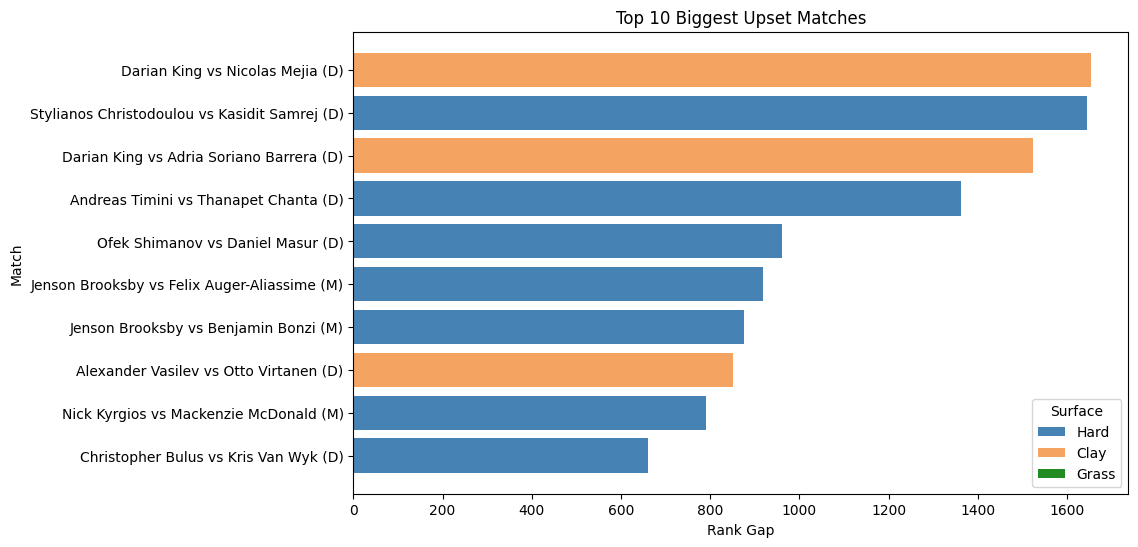

In [68]:
# Bar chart of the 10 biggest upsets
from matplotlib.patches import Patch

# Bar chart of the 10 biggest upsets with colors by surface
plot_top10 = upset_only.sort_values('rank_gap', ascending=False).head(10).copy()
plot_top10['match_label'] = (
    plot_top10['winner_name'] + ' vs ' + plot_top10['loser_name']
    + ' (' + plot_top10['tourney_level'] + ')'
)
plot_top10 = plot_top10.sort_values('rank_gap')

surface_colors = {
    'Hard': 'steelblue',
    'Clay': 'sandybrown',
    'Grass': 'forestgreen'
}

bar_colors = plot_top10['surface'].map(surface_colors)

plt.figure(figsize=(10, 6))
plt.barh(plot_top10['match_label'], plot_top10['rank_gap'], color=bar_colors)
plt.title('Top 10 Biggest Upset Matches')
plt.xlabel('Rank Gap')
plt.ylabel('Match')

legend_elements = [
    Patch(facecolor='steelblue', label='Hard'),
    Patch(facecolor='sandybrown', label='Clay'),
    Patch(facecolor='forestgreen', label='Grass')
]

plt.legend(handles=legend_elements, title='Surface')
plt.show()

**Most Extreme Upset Matches Notes**

- The biggest upset list shows that many of the most extreme matches came from Davis Cup and round-robin situations. This makes sense because those match settings seem to include much wider ranking differences than regular ATP tournaments.

- For that reason, I also looked at a version without Davis Cup. That second list makes it easier to see which upset matches stood out in a more normal ATP tournament setting, instead of having the results mostly dominated by a few very unusual cases.

- Looking at the biggest upset by surface and tournament level also makes the results easier to understand. Hard and clay had the most extreme cases overall, but grass also had a notable example, so large upsets were not limited to only one surface.

- The tournament-level examples also show that upset size depends a lot on match context. ATP Finals had only a very small rank-gap upset, while Davis Cup had much larger ones, which fits the different structure of those events.

### **10. Final Interpretation and Limitations**

Results

- In this project, I looked at upset matches in the 2025 ATP Tour using ranking-based match data. It contains publicly available professional match records and did not include personal contact information, health records, or private identifying information. No sensitive personal data were used in the analysis.

- Overall, upset matches happened less often than non-upset matches, but they still made up a pretty large part of the dataset. So even though the higher-ranked player won more often, unexpected results still happened often enough to show meaningful patterns.

- From the analysis, surface did not seem to make a very large difference by itself. The upset rates across grass, hard, and clay were fairly close. Tournament level seemed a little more useful, since ATP 250 events kept showing relatively high upset rates. Round also seemed to matter somewhat, especially in the earliest rounds, but those differences were not as strong or as consistent as the tournament-level differences.

- When I compared upset and non-upset matches more directly, upset matches were usually longer and happened at smaller rank gaps. This makes it seem like many upsets happen in matches where the two players are still somewhat close in ranking, even if one player is technically lower-ranked. The ace results also suggested that upset winners were still ahead in aces, but not by as much as winners in non-upset matches. The double-fault results looked more similar across both groups.

Ethics and Impact

- At the same time, I think there are some important ethical and interpretive limits in this project.

- First, I defined upset matches only by ranking difference. That is useful for analysis, but it is still a simplified definition. Rankings do not fully capture things like injury, current form, fatigue, or surface-specific strengths, so a ranking-based upset does not always mean the match was truly surprising in a broader sense. Also, unranked players or matches with missing ranking data are underrepresented in the upset classification because those matches could not be labeled using the ranking-based definition.

- Second, this dataset came from a public secondary tennis database rather than an official ATP source. Because of that, I think the results should be treated carefully rather than as a perfect record of reality.

- Third, some match types such as Davis Cup, ATP Finals, and round-robin events are different from regular ATP tournaments. They are still part of the 2025 data, so I did not want to remove them completely, but I also do not think they should be interpreted in exactly the same way as standard ATP tour matches. Because lower-level tournaments or special formats such as Davis Cup and round-robin events may be overrepresented in extreme upset cases, which can make the largest upsets seem more common than they are in standard ATP events.

- Finally, I do not think this kind of analysis should be used to make strong judgments about individual players. The goal is to study general patterns, not to reduce a player or a match to one simplified label.

- If I continued this project, I would want to compare 2025 with other seasons and also look at whether large upset matches got more media attention. But even that would need careful interpretation, because visibility in sports is not distributed equally either.